In [2]:
import pandas as pd
import matplotlib.pyplot as plt
class PizzaBot:
    def __init__(self):
        self.menu = {
            'pizzas': {
                'Pepperoni Pizza': {'large': 12.95, 'medium': 10.00, 'small': 7.00},
                'Cheese Pizza': {'large': 12.00, 'medium': 8.00, 'small': 6.00},
                'Veggie Pizza': {'large': 11.50, 'medium': 9.20, 'small': 6.80}
            },
            'sides': {
                'Fries': {'large': 5.00, 'medium': 4.00, 'small': 3.00},
                'Salad': {'large': 3.55, 'medium': 3.00, 'small': 2.00},
                'Chicken Wings': {'large': 6.50, 'medium': 5.20, 'small': 4.00}
            },
            'toppings': {
                'Mushroom': 1.00,
                'BBQ Sauce': 0.50,
                'Peppers': 0.20,
                'Extra Cheese': 1.20
            },
            'drinks': {
                'Cola': {'large': 2.85, 'medium': 2.00, 'small': 1.50},
                'Americano': {'large': 3.20, 'medium': 2.60, 'small': 2.00},
                'Orange Juice': {'large': 3.00, 'medium': 2.40, 'small': 1.80}
            }
        }

        self.size_options = {
            '1': 'large',
            '2': 'medium',
            '3': 'small'
        }

        self.discount_threshold = 20
        self.discount_rate = 0.10
        self.delivery_fee = 2.50

    def menu_to_dataframe(self):
        rows = []

        for category, items in self.menu.items():
            for item_name, price_info in items.items():
                if isinstance(price_info, dict):
                    for size, price in price_info.items():
                        rows.append({
                            'category': category,
                            'item': item_name,
                            'size': size,
                            'price': price
                        })
                else:
                    rows.append({
                        'category': category,
                        'item': item_name,
                        'size': 'one size',
                        'price': price_info
                    })

        return pd.DataFrame(rows)

    def get_price(self, category, item, size=None):
        price_info = self.menu[category][item]

        if isinstance(price_info, dict):
            return price_info[size]
        else:
            return price_info

    def create_order(
        self,
        pizza_type,
        pizza_size,
        toppings=None,
        side=None,
        side_size=None,
        drink=None,
        drink_size=None,
        delivery=True
    ):
        if toppings is None:
            toppings = []

        order_lines = []

        pizza_price = self.get_price('pizzas', pizza_type, pizza_size)
        order_lines.append({
            'item': pizza_type,
            'category': 'pizza',
            'size': pizza_size,
            'price': pizza_price
        })

        for topping in toppings:
            topping_price = self.get_price('toppings', topping)
            order_lines.append({
                'item': topping,
                'category': 'topping',
                'size': 'one size',
                'price': topping_price
            })

        if side is not None:
            side_price = self.get_price('sides', side, side_size)
            order_lines.append({
                'item': side,
                'category': 'side',
                'size': side_size,
                'price': side_price
            })

        if drink is not None:
            drink_price = self.get_price('drinks', drink, drink_size)
            order_lines.append({
                'item': drink,
                'category': 'drink',
                'size': drink_size,
                'price': drink_price
            })

        subtotal = sum(line['price'] for line in order_lines)

        if subtotal >= self.discount_threshold:
            discount = subtotal * self.discount_rate
        else:
            discount = 0

        fee = self.delivery_fee if delivery else 0
        total = subtotal - discount + fee

        summary = {
            'subtotal': subtotal,
            'discount': discount,
            'delivery_fee': fee,
            'total': total
        }

        return order_lines, summary

    def print_receipt(self, order_lines, summary):
        print("=" * 45)
        print("PizzaBot Receipt")
        print("=" * 45)

        for line in order_lines:
            print(
                f"{line['item']:20s} "
                f"{line['size']:10s} "
                f"${line['price']:.2f}"
            )

        print("-" * 45)
        print(f"Subtotal:      ${summary['subtotal']:.2f}")
        print(f"Discount:     -${summary['discount']:.2f}")
        print(f"Delivery Fee:  ${summary['delivery_fee']:.2f}")
        print(f"Total:         ${summary['total']:.2f}")
        print("=" * 45)
        print("Thanks for your order. Your food is being prepared now!")

In [3]:
bot = PizzaBot()

menu_df = bot.menu_to_dataframe()
menu_df

,category,item,size,price
0,pizzas,Pepperoni Pizza,large,12.95
1,pizzas,Pepperoni Pizza,medium,10.00
2,pizzas,Pepperoni Pizza,small,7.00
3,pizzas,Cheese Pizza,large,12.00
4,pizzas,Cheese Pizza,medium,8.00
5,pizzas,Cheese Pizza,small,6.00
6,pizzas,Veggie Pizza,large,11.50
7,pizzas,Veggie Pizza,medium,9.20
8,pizzas,Veggie Pizza,small,6.80
9,sides,Fries,large,5.00


In [4]:
order_lines, summary = bot.create_order(
    pizza_type='Pepperoni Pizza',
    pizza_size='large',
    toppings=['Mushroom', 'Extra Cheese'],
    side='Fries',
    side_size='medium',
    drink='Cola',
    drink_size='large',
    delivery=True
)

bot.print_receipt(order_lines, summary)

PizzaBot Receipt
Pepperoni Pizza      large      $12.95
Mushroom             one size   $1.00
Extra Cheese         one size   $1.20
Fries                medium     $4.00
Cola                 large      $2.85
---------------------------------------------
Subtotal:      $22.00
Discount:     -$2.20
Delivery Fee:  $2.50
Total:         $22.30
Thanks for your order. Your food is being prepared now!


In [5]:
order_df = pd.DataFrame(order_lines)
order_df

,item,category,size,price
0,Pepperoni Pizza,pizza,large,12.95
1,Mushroom,topping,one size,1.00
2,Extra Cheese,topping,one size,1.20
3,Fries,side,medium,4.00
4,Cola,drink,large,2.85


In [6]:
discount_check = pd.DataFrame({
    'subtotal': [summary['subtotal']],
    'discount_threshold': [bot.discount_threshold],
    'discount_rate': [bot.discount_rate],
    'discount_applied': [summary['discount'] > 0],
    'discount_amount': [round(summary['discount'], 2)]
})

discount_check

,subtotal,discount_threshold,discount_rate,discount_applied,discount_amount
0,22.0,20,0.1,True,2.2


In [7]:
sample_orders = [
    {
        'name': 'Order A',
        'pizza_type': 'Cheese Pizza',
        'pizza_size': 'small',
        'toppings': ['Peppers'],
        'side': None,
        'side_size': None,
        'drink': 'Cola',
        'drink_size': 'small',
        'delivery': False
    },
    {
        'name': 'Order B',
        'pizza_type': 'Pepperoni Pizza',
        'pizza_size': 'large',
        'toppings': ['Mushroom', 'Extra Cheese'],
        'side': 'Fries',
        'side_size': 'medium',
        'drink': 'Cola',
        'drink_size': 'large',
        'delivery': True
    },
    {
        'name': 'Order C',
        'pizza_type': 'Veggie Pizza',
        'pizza_size': 'medium',
        'toppings': ['BBQ Sauce', 'Peppers'],
        'side': 'Salad',
        'side_size': 'small',
        'drink': 'Americano',
        'drink_size': 'medium',
        'delivery': True
    }
]

summary_rows = []

for order in sample_orders:
    lines, order_summary = bot.create_order(
        pizza_type=order['pizza_type'],
        pizza_size=order['pizza_size'],
        toppings=order['toppings'],
        side=order['side'],
        side_size=order['side_size'],
        drink=order['drink'],
        drink_size=order['drink_size'],
        delivery=order['delivery']
    )

    summary_rows.append({
        'order': order['name'],
        'pizza': order['pizza_type'],
        'size': order['pizza_size'],
        'subtotal': round(order_summary['subtotal'], 2),
        'discount': round(order_summary['discount'], 2),
        'delivery_fee': round(order_summary['delivery_fee'], 2),
        'total': round(order_summary['total'], 2)
    })

order_summary_df = pd.DataFrame(summary_rows)
order_summary_df

,order,pizza,size,subtotal,discount,delivery_fee,total
0,Order A,Cheese Pizza,small,7.7,0.0,0.0,7.7
1,Order B,Pepperoni Pizza,large,22.0,2.2,2.5,22.3
2,Order C,Veggie Pizza,medium,14.5,0.0,2.5,17.0


In [8]:
cheapest_rows = []

for pizza_name, prices in bot.menu['pizzas'].items():
    cheapest_size = min(prices, key=prices.get)
    cheapest_price = prices[cheapest_size]

    cheapest_rows.append({
        'pizza': pizza_name,
        'cheapest_size': cheapest_size,
        'cheapest_price': cheapest_price
    })

cheapest_pizza_df = pd.DataFrame(cheapest_rows)
cheapest_pizza_df

,pizza,cheapest_size,cheapest_price
0,Pepperoni Pizza,small,7.0
1,Cheese Pizza,small,6.0
2,Veggie Pizza,small,6.8


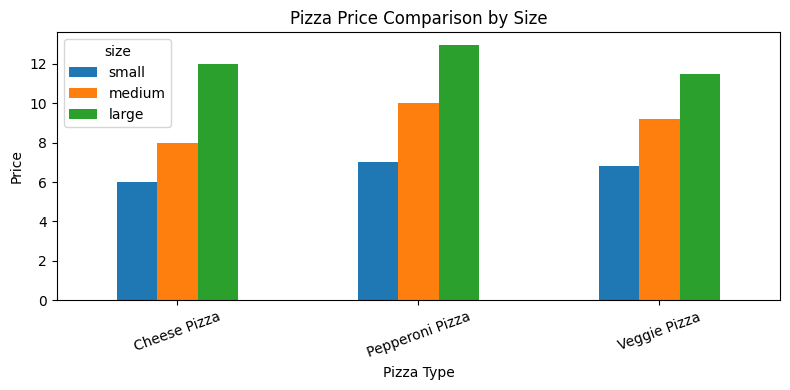

In [9]:
pizza_price_rows = []

for pizza_name, prices in bot.menu['pizzas'].items():
    for size, price in prices.items():
        pizza_price_rows.append({
            'pizza': pizza_name,
            'size': size,
            'price': price
        })

pizza_price_df = pd.DataFrame(pizza_price_rows)

pivot_price = pizza_price_df.pivot(index='pizza', columns='size', values='price')
pivot_price = pivot_price[['small', 'medium', 'large']]

ax = pivot_price.plot(kind='bar', figsize=(8, 4))

plt.title("Pizza Price Comparison by Size")
plt.xlabel("Pizza Type")
plt.ylabel("Price")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

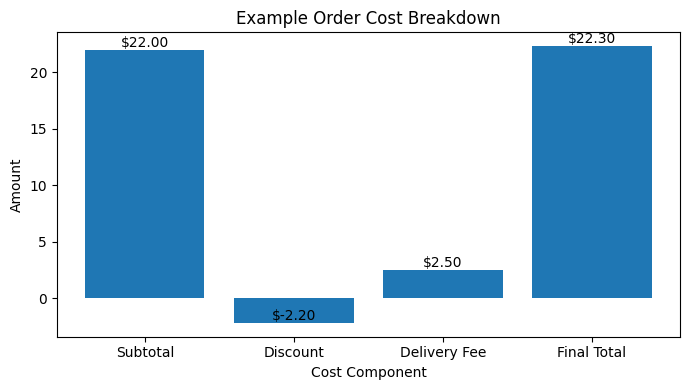

In [10]:
cost_breakdown = pd.DataFrame({
    'component': ['Subtotal', 'Discount', 'Delivery Fee', 'Final Total'],
    'amount': [
        summary['subtotal'],
        -summary['discount'],
        summary['delivery_fee'],
        summary['total']
    ]
})

plt.figure(figsize=(7, 4))
plt.bar(cost_breakdown['component'], cost_breakdown['amount'])

for i, amount in enumerate(cost_breakdown['amount']):
    plt.text(i, amount, f"${amount:.2f}", ha='center', va='bottom')

plt.title("Example Order Cost Breakdown")
plt.xlabel("Cost Component")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

In [11]:
def interactive_order():
    bot = PizzaBot()

    print("Welcome to the pizza store!")

    pizza_list = list(bot.menu['pizzas'].keys())
    side_list = list(bot.menu['sides'].keys())
    drink_list = list(bot.menu['drinks'].keys())
    topping_list = list(bot.menu['toppings'].keys())

    print("\nChoose pizza:")
    for i, item in enumerate(pizza_list, start=1):
        print(f"{i}. {item}")

    pizza_choice = int(input("Your pizza choice: ")) - 1
    pizza_type = pizza_list[pizza_choice]

    print("\nChoose size:")
    print("1. large")
    print("2. medium")
    print("3. small")

    size_choice = input("Your size choice: ")
    pizza_size = bot.size_options[size_choice]

    print("\nChoose one topping or press Enter to skip:")
    for i, item in enumerate(topping_list, start=1):
        print(f"{i}. {item}")

    topping_choice = input("Your topping choice: ")

    if topping_choice.strip() == "":
        toppings = []
    else:
        toppings = [topping_list[int(topping_choice) - 1]]

    print("\nChoose side or press Enter to skip:")
    for i, item in enumerate(side_list, start=1):
        print(f"{i}. {item}")

    side_choice = input("Your side choice: ")

    if side_choice.strip() == "":
        side = None
        side_size = None
    else:
        side = side_list[int(side_choice) - 1]
        side_size = pizza_size

    print("\nChoose drink or press Enter to skip:")
    for i, item in enumerate(drink_list, start=1):
        print(f"{i}. {item}")

    drink_choice = input("Your drink choice: ")

    if drink_choice.strip() == "":
        drink = None
        drink_size = None
    else:
        drink = drink_list[int(drink_choice) - 1]
        drink_size = pizza_size

    lines, order_summary = bot.create_order(
        pizza_type=pizza_type,
        pizza_size=pizza_size,
        toppings=toppings,
        side=side,
        side_size=side_size,
        drink=drink,
        drink_size=drink_size,
        delivery=True
    )

    bot.print_receipt(lines, order_summary)


interactive_order()

Welcome to the pizza store!

Choose pizza:
1. Pepperoni Pizza
2. Cheese Pizza
3. Veggie Pizza
Your pizza choice: 1

Choose size:
1. large
2. medium
3. small
Your size choice: 2

Choose one topping or press Enter to skip:
1. Mushroom
2. BBQ Sauce
3. Peppers
4. Extra Cheese
Your topping choice: 3

Choose side or press Enter to skip:
1. Fries
2. Salad
3. Chicken Wings
Your side choice: 1

Choose drink or press Enter to skip:
1. Cola
2. Americano
3. Orange Juice
Your drink choice: 2
PizzaBot Receipt
Pepperoni Pizza      medium     $10.00
Peppers              one size   $0.20
Fries                medium     $4.00
Americano            medium     $2.60
---------------------------------------------
Subtotal:      $16.80
Discount:     -$0.00
Delivery Fee:  $2.50
Total:         $19.30
Thanks for your order. Your food is being prepared now!


class PizzaBot:
This line defines a class called PizzaBot. This class represents a pizza ordering bot.

def __init__(self):

In Python, the __init__ method is a special method that is automatically called when an object of a class is created. It is commonly used to initialize the attributes (or properties) of the object. In the context of an ordering bot, the __init__ method is used to initialize the initial state of the bot.

In the provided code, the __init__ method of the PizzaBot class defines the initial state of the bot by initializing its menu attribute. The menu attribute is a dictionary that contains information about the available items on the menu, organized into different categories such as 'pizzas', 'sides', 'toppings', and 'drinks'. Each category contains specific items with their respective prices.



    The 'pizzas' category contains two pizza types: 'Pepperoni Pizza' and 'Cheese Pizza'. Each pizza type has different prices based on their size. The prices are represented as a nested dictionary, where the keys are the sizes ('large', 'medium', 'small') and the values are the corresponding prices.

    The 'sides' category contains two side options: 'Fries' and 'Salad'. Similar to pizzas, each side has different prices based on size.

    The 'toppings' category contains three topping options: 'Mushroom', 'BBQ Sauce', and 'Peppers'. Toppings do not have different sizes, so the prices are directly associated with the toppings as individual values.

    The 'drinks' category contains two drink options: 'Cola' and 'Americano'. Similar to pizzas and sides, each drink has different prices based on size.

By initializing the menu attribute in the __init__ method, the PizzaBot object will have access to the menu data, allowing it to present the options to the user and retrieve the corresponding information when the user makes selections.

Details about class can be found here: https://www.geeksforgeeks.org/python-classes-and-objects/
Details about def and return:
https://sites.pitt.edu/~naraehan/python3/user_defined_functions.html




    

In Python, the if __name__ == "__main__" block is used to check whether the current script is being executed as the main program or being imported as a module.

When a Python module is imported into another script, the code within the module is executed. However, sometimes you may want to have certain code in the module that should only run when the module is run directly as the main program, and not when it is imported.

The if __name__ == "__main__" condition allows you to specify which parts of the code should only be executed when the module is run directly.

In the provided code, the if __name__ == "__main__" condition is used to check if the script is being run directly. If it is the main script being executed, the main() function is called.
